In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_text
import xgboost as xgb




In [58]:
df = pd.read_csv(r'C:\Users\TALIGENT\git\ML-ZOOMCAMP-HOMEWORK\First Proyect\Dataset\online_shoppers_intention.csv')
df.head().T

,0,1,2,3,4
Administrative,0,0,0,0,0
Administrative_Duration,0.0,0.0,0.0,0.0,0.0
Informational,0,0,0,0,0
Informational_Duration,0.0,0.0,0.0,0.0,0.0
ProductRelated,1,2,1,2,10
ProductRelated_Duration,0.0,64.0,0.0,2.666667,627.5
BounceRates,0.2,0.0,0.2,0.05,0.02
ExitRates,0.2,0.1,0.2,0.14,0.05
PageValues,0.0,0.0,0.0,0.0,0.0
SpecialDay,0.0,0.0,0.0,0.0,0.0


## EDA

In [59]:
def camel_to_snake(name):
    name = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    name = re.sub('([a-z0-9])([A-Z])', r'\1_\2', name)
    return name.lower()

df.columns = [camel_to_snake(col) for col in df.columns]
df.columns = df.columns.str.replace('__', '_', regex=False)

features_categoricas = list(df.dtypes[df.dtypes == 'object'].index)
for c in features_categoricas:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [60]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   administrative            12330 non-null  int64  
 1   administrative_duration   12330 non-null  float64
 2   informational             12330 non-null  int64  
 3   informational_duration    12330 non-null  float64
 4   product_related           12330 non-null  int64  
 5   product_related_duration  12330 non-null  float64
 6   bounce_rates              12330 non-null  float64
 7   exit_rates                12330 non-null  float64
 8   page_values               12330 non-null  float64
 9   special_day               12330 non-null  float64
 10  month                     12330 non-null  object 
 11  operating_systems         12330 non-null  int64  
 12  browser                   12330 non-null  int64  
 13  region                    12330 non-null  int64  
 14  traffi

In [ ]:
#Convierto features booleanas a binarias
df['revenue'] = df['revenue'].astype(int)
df['weekend'] = df['weekend'].astype(int)

In [62]:
# Hay un desbalanceo
df['revenue'].value_counts(normalize=True) * 100

revenue
0    84.525547
1    15.474453
Name: proportion, dtype: float64

In [139]:
# Son variables codificadas en numeros pero categoricas
cols_to_str = ['operating_systems', 'browser', 'region', 'traffic_type']
df[cols_to_str] = df[cols_to_str].astype(str)

df.head().T

,0,1,2,3,4
administrative,0,0,0,0,0
administrative_duration,0.0,0.0,0.0,0.0,0.0
informational,0,0,0,0,0
informational_duration,0.0,0.0,0.0,0.0,0.0
product_related,1,2,1,2,10
product_related_duration,0.0,64.0,0.0,2.666667,627.5
bounce_rates,0.2,0.0,0.2,0.05,0.02
exit_rates,0.2,0.1,0.2,0.14,0.05
page_values,0.0,0.0,0.0,0.0,0.0
special_day,0.0,0.0,0.0,0.0,0.0


## Split DF

In [64]:
# Configuracion del Marco de Trabajo
# Usaremos Scikit-Learn para divivir en train - val- test

df_full_train, df_test =train_test_split(df, test_size=0.2, random_state=1)

df_train, df_val =train_test_split(df_full_train, test_size=0.25, random_state=1) 

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test= df_test.reset_index(drop=True)
df_full_train.reset_index(drop= True)

y_train = df_train.revenue.values
y_val = df_val.revenue.values
y_test = df_test.revenue.values
y_full_train = df_full_train.revenue.values


del df_train['revenue']
del df_val['revenue']
del df_test['revenue']
del df_full_train ['revenue']


In [65]:
categoricas = [
    'month',
    'visitor_type',
    'weekend',
    'operating_systems',
    'browser',
    'region',
    'traffic_type',
    
]

numericas = [
    'administrative',
    'administrative_duration',
    'informational',
    'informational_duration',
    'product_related',
    'product_related_duration',
    'bounce_rates',
    'exit_rates',
    'page_values',
    'special_day'
]

## Informacion sobre Features

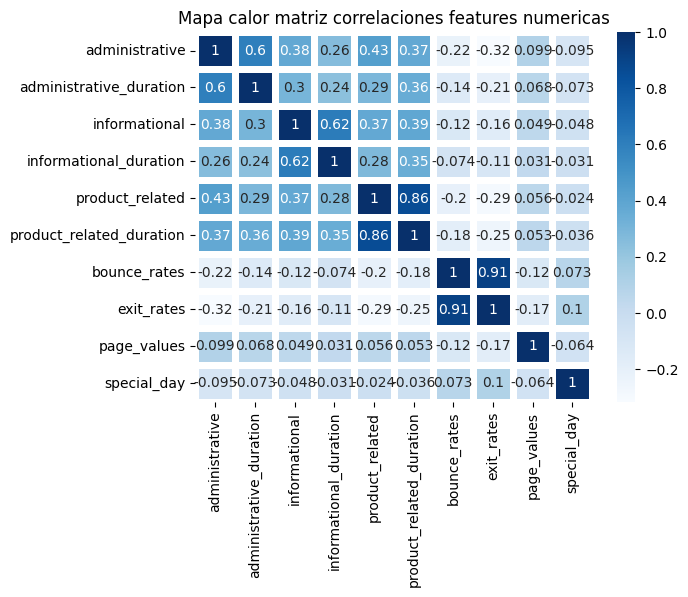

In [66]:
matrix_corr_num = df[numericas].corr
sns.heatmap(matrix_corr_num(),annot=True, linewidths=5, cmap='Blues')
plt.title('Mapa calor matriz correlaciones features numericas')
plt.show()

In [67]:
# La mayor correlacion es entre  estas dos  variables numericas : "bounce_rates" "exit_rates"
# que al usar Ramdom forest eliminamos esta multicolinealidad ya que es un modelo robusto y no afecta

In [68]:
# Informacion mutua entre variables
from sklearn.metrics import mutual_info_score

def info_mutua_y(series):
    return mutual_info_score(y_train,series)

im = df_train[categoricas].apply(info_mutua_y).round(2)
im.sort_values(ascending=False)



month                0.02
traffic_type         0.02
visitor_type         0.01
weekend              0.00
operating_systems    0.00
browser              0.00
region               0.00
dtype: float64

In [69]:
# CONCLUSION ANALISIS DE VARIABLES
# Num: La mayor correlacion es entre  estas dos  variables numericas : "bounce_rates" "exit_rates"
#   que al usar Ramdom forest eliminamos esta multicolinealidad ya que es un modelo robusto y no afecta
# Cat: Tráfico y Estacionalidad  Las variables traffic_type y month son las que aportan mayor información
#   sobre la compra, lo que confirma que las fuentes de tráfico y la estacionalidad 
#   (ej., meses de alto consumo como nov o dec tienen la relación más fuerte con la variable objetivo

## X_TRAIN / X_VAL

In [70]:
# Se escala para mejorar la performance en el entrenamiento num_interacciones
scaler = StandardScaler()
df_train[numericas] = scaler.fit_transform(df_train[numericas])
df_val[numericas]   = scaler.transform(df_val[numericas])

In [71]:
# Armo funcion para obtener X_train y X_val
def Dict_Vect (df_train, df_val):
    train_dict = df_train[categoricas + numericas].to_dict(orient = 'records')
    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(train_dict)

    val_dict = df_val[categoricas + numericas].to_dict(orient='records')
    X_val = dv.transform(val_dict) 

    return X_train, X_val,dv

X_train, X_val, dv = Dict_Vect(df_train,df_val)



In [72]:
# Validamos las columnas creadas en el diccionario
feature_names = dv.get_feature_names_out()
feature_names


array(['administrative', 'administrative_duration', 'bounce_rates',
       'browser=1', 'browser=10', 'browser=11', 'browser=12',
       'browser=13', 'browser=2', 'browser=3', 'browser=4', 'browser=5',
       'browser=6', 'browser=7', 'browser=8', 'exit_rates',
       'informational', 'informational_duration', 'month=aug',
       'month=dec', 'month=feb', 'month=jul', 'month=june', 'month=mar',
       'month=may', 'month=nov', 'month=oct', 'month=sep',
       'operating_systems=1', 'operating_systems=2',
       'operating_systems=3', 'operating_systems=4',
       'operating_systems=5', 'operating_systems=6',
       'operating_systems=7', 'operating_systems=8', 'page_values',
       'product_related', 'product_related_duration', 'region=1',
       'region=2', 'region=3', 'region=4', 'region=5', 'region=6',
       'region=7', 'region=8', 'region=9', 'special_day',
       'traffic_type=1', 'traffic_type=10', 'traffic_type=11',
       'traffic_type=13', 'traffic_type=14', 'traffic_type=15

## MODEL LOGISTIC REGRESSION (MODEL 1 "M1")

In [73]:
# Entreno el modelo
model = LogisticRegression(max_iter= 100, random_state=42)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [74]:
# Primer Modelo REGRESION ACCURACY

y_pred_prob = model.predict_proba(X_val)[:, 1]
y_pred= model.predict(X_val)
score = accuracy_score(y_val, y_pred)

sc_M1 = roc_auc_score(y_val,y_pred_prob)
F1_accurracy = f1_score(y_val,y_pred)

F1_accurracy




0.5165562913907285

In [75]:
# En este caso vemos que esta muy desbalanceada la feature que tenemos que predecir 
# por lo cual necsitamos usar la roc_auc.
# Tenemos ver ahora F1 y los trees para evaluar el modelo.

## MODEL DECISION TREE CLASIFFIER (MODEL 2 "M2")

In [76]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [77]:

max_depth = [1,2,3,4,5,6]

for d in max_depth:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)

    y_pred = dt.predict_proba(X_train)[:, 1]
    auc = roc_auc_score(y_train, y_pred)
    print(d,'train:', auc)

    y_pred = dt.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    print(d,'val:', auc)


1 train: 0.8250828534168035
1 val: 0.8491033051726694
2 train: 0.8815950790316873
2 val: 0.8999419495084234
3 train: 0.899444577152934
3 val: 0.9137789634899461
4 train: 0.912063160439613
4 val: 0.918764512622894
5 train: 0.9255321094722643
5 val: 0.9230954498295539
6 train: 0.9374445873295435
6 val: 0.908418556395435


<Axes: xlabel='max_depth', ylabel='min_samples_leaf'>

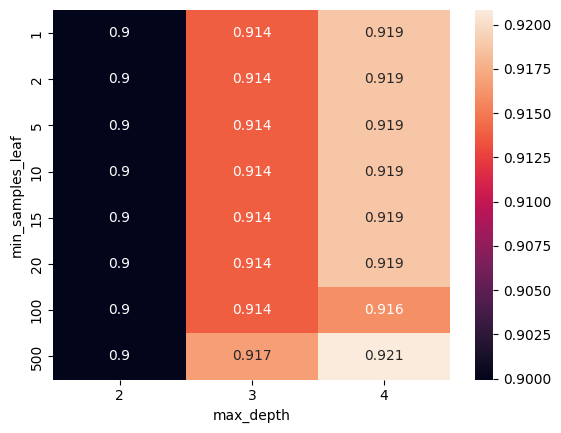

In [78]:
scores = []

for d in [2,3,4]:
    for s in [1,2,5,10,15,20,100,500]:
        dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=s)
        dt.fit(X_train, y_train)
        y_pred = dt.predict_proba(X_val)[:,1] 
        auc = roc_auc_score(y_val,y_pred)
        scores.append((d,s,auc))


columns = ['max_depth', 'min_samples_leaf', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores = df_scores.sort_values(by='auc', ascending=False)

df_scores_pivot = df_scores.pivot(columns='max_depth', index='min_samples_leaf', values='auc')
sns.heatmap(df_scores_pivot,annot=True,fmt=".3g")

En este caso analizamos los distintos max_depth y vemos cual es el que maximiza al modelo, teniendo en cuenta el riesgo de overfigthing.
Haciendo un analisis seria el optimo el max_depth 3

In [79]:
dt = DecisionTreeClassifier(max_depth=4,min_samples_leaf=500, random_state=42)
dt.fit(X_train, y_train)

y_pred_prob = dt.predict_proba(X_val)[:, 1]
y_pred = dt.predict(X_val)


sc_M2 = roc_auc_score(y_val, y_pred_prob)
F1_TreeClassifier = f1_score(y_val,y_pred)



## MODEL RANDOM FOREST (MODEL 3 "M3")

In [80]:
scores = []
for d in [5,10,15]:
    for r in range(10,201,10):
        rf = RandomForestClassifier(n_estimators=r,max_depth=d, random_state=42)
        rf.fit(X_train,y_train)
        y_pred = rf.predict_proba(X_val)[:,1]
        auc = roc_auc_score(y_val,y_pred)
        scores.append((d,r,auc))
scores

[(5, 10, 0.910321253890618),
 (5, 20, 0.9176701991008349),
 (5, 30, 0.9218757719480264),
 (5, 40, 0.9227360308285164),
 (5, 50, 0.9241786473000346),
 (5, 60, 0.9251914431105183),
 (5, 70, 0.9254681092831382),
 (5, 80, 0.9257867694283879),
 (5, 90, 0.926156069364162),
 (5, 100, 0.9248900746010572),
 (5, 110, 0.9251939133442023),
 (5, 120, 0.9253569487673534),
 (5, 130, 0.9253594190010375),
 (5, 140, 0.9249678869621066),
 (5, 150, 0.9251222765673632),
 (5, 160, 0.9251827972926239),
 (5, 170, 0.9255730942147128),
 (5, 180, 0.9255866804999753),
 (5, 190, 0.9255817400326072),
 (5, 200, 0.9256447309915519),
 (10, 10, 0.9211575515043722),
 (10, 20, 0.9281915419198655),
 (10, 30, 0.9312225186502643),
 (10, 40, 0.9329763845659801),
 (10, 50, 0.9318623091744479),
 (10, 60, 0.9326910725754658),
 (10, 70, 0.9334778420038534),
 (10, 80, 0.9339101328985723),
 (10, 90, 0.9341485104490886),
 (10, 100, 0.9338706091596265),
 (10, 110, 0.9346042685638061),
 (10, 120, 0.9345054592164419),
 (10, 130, 0.934

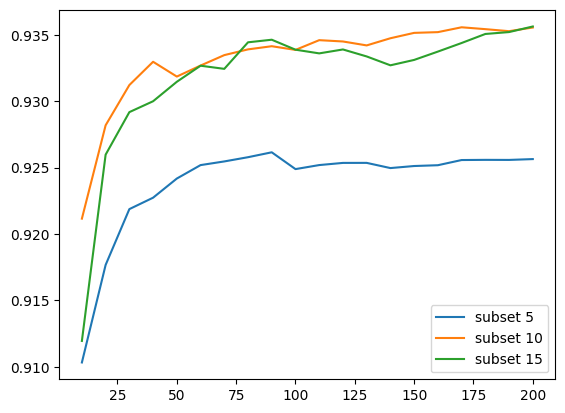

In [81]:
df_scores= pd.DataFrame(scores, columns=['max_depth','n_estimators','auc'])
for d in [5,10,15]:
    df_subset = df_scores[df_scores.max_depth ==d]
    plt.plot(df_subset.n_estimators, df_subset.auc, label = f'subset {d}' )
    plt.legend()

In [82]:
df_scores_ordenado_md = df_scores.sort_values(by='auc', ascending=False)
df_scores_ordenado_md

,max_depth,n_estimators,auc
59,15,200,0.935636
36,10,170,0.935575
39,10,200,0.935558
37,10,180,0.935434
38,10,190,0.935281
58,15,190,0.935214
35,10,160,0.935209
34,10,150,0.935154
57,15,180,0.935071
33,10,140,0.934749


En max_depth = 10 en los 5 primeros esta el 10 y luego para cuando elijamos el min_samples_leaf nos da mas margen

In [83]:
max_depth = 10

scores = []

for s in [1, 5, 10, 20, 50, 100]:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n,
                                    max_depth=max_depth,
                                    min_samples_leaf=s,
                                    random_state=42)
        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        scores.append((s, n, auc))


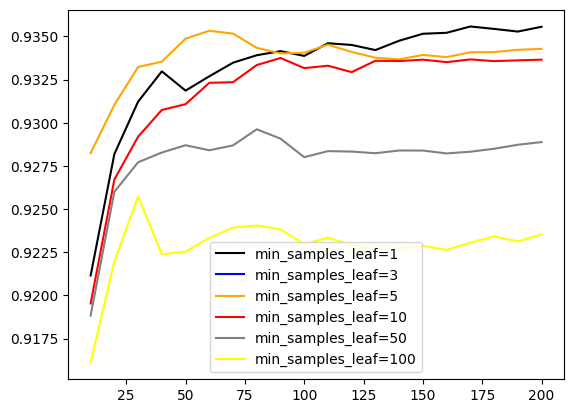

In [84]:
columns = ['min_samples_leaf', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)

colors = ['black', 'blue', 'orange', 'red', 'grey', 'yellow' ]
values = [1, 3, 5, 10, 50, 100]

for s, col in zip(values, colors):
    df_subset = df_scores[df_scores.min_samples_leaf == s]
    
    plt.plot(df_subset.n_estimators, df_subset.auc,
             color=col,
             label='min_samples_leaf=%d' % s)

plt.legend()

In [85]:
df_scores.sort_values(by='auc', ascending=False)

,min_samples_leaf,n_estimators,auc
16,1,170,0.935575
19,1,200,0.935558
17,1,180,0.935434
25,5,60,0.935327
18,1,190,0.935281
...,...,...,...
0,1,10,0.921158
40,10,10,0.919538
60,20,10,0.919265
80,50,10,0.918841


Despues del Tunning a las variables, vemos que los valores de las mismas donde se obtiene un auc mas optimos son:
 

In [86]:
n_estimators= 170
max_depth = 10
min_samples_leaf = 1

rf = RandomForestClassifier(n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_leaf=min_samples_leaf,
    random_state=42)
rf.fit(X_train, y_train)

y_pred_prob = rf.predict_proba(X_val)[:, 1]
y_pred= rf.predict(X_val)
sc_M3 = roc_auc_score(y_val, y_pred_prob)
F1_RandomForest = f1_score(y_val, y_pred)

sc_M1,F1_accurracy, sc_M2,F1_TreeClassifier, sc_M3,F1_RandomForest



(0.8983214762116496,
 0.5165562913907285,
 0.920823452398597,
 0.551948051948052,
 0.93557507040166,
 0.5955414012738853)

## MODEL XGBOOST (MODEL 4 "M4")

In [87]:
features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [88]:
def get_xgb_scores(evals_result):
    train_aucs = list(evals_result['train'].values())[0]
    val_aucs = list(evals_result['val'].values())[0]

    # Definimos los nombres de las columnas
    columns = ['iter', 'train_auc', 'val_auc']

    # Creamos un DataFrame combinando la lista de iteraciones, train_aucs y val_aucs
    df_results = pd.DataFrame(
        list(zip(
            # Generamos la columna de iteración (desde 1 hasta el final)
            range(1, len(train_aucs) + 1),
            train_aucs,
            val_aucs
        )), 
        columns=columns
    )
    
    return df_results


In [89]:
scores = {}

In [90]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [91]:

xgb_params = {
    'eta': 0.1, 
    'max_depth': 3,
    'min_child_weight': 1,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 42,
    'verbosity': 1,
}

evals_result = {}
model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist,
                  evals_result=evals_result)

key = f'eta={xgb_params['eta']}'
scores[key] = get_xgb_scores(evals_result)


[0]	train-auc:0.89986	val-auc:0.91438
[5]	train-auc:0.92035	val-auc:0.93035
[10]	train-auc:0.92471	val-auc:0.93375
[15]	train-auc:0.92905	val-auc:0.93668
[20]	train-auc:0.93053	val-auc:0.93670
[25]	train-auc:0.93235	val-auc:0.93747
[30]	train-auc:0.93526	val-auc:0.93944
[35]	train-auc:0.93671	val-auc:0.93989
[40]	train-auc:0.93759	val-auc:0.93958
[45]	train-auc:0.93868	val-auc:0.94023
[50]	train-auc:0.93960	val-auc:0.94052
[55]	train-auc:0.94050	val-auc:0.94021
[60]	train-auc:0.94109	val-auc:0.94026
[65]	train-auc:0.94161	val-auc:0.94032
[70]	train-auc:0.94230	val-auc:0.94019
[75]	train-auc:0.94297	val-auc:0.94021
[80]	train-auc:0.94386	val-auc:0.94005
[85]	train-auc:0.94455	val-auc:0.93968
[90]	train-auc:0.94519	val-auc:0.93971
[95]	train-auc:0.94579	val-auc:0.93965
[100]	train-auc:0.94655	val-auc:0.93984
[105]	train-auc:0.94724	val-auc:0.94019
[110]	train-auc:0.94771	val-auc:0.94009
[115]	train-auc:0.94835	val-auc:0.93993
[120]	train-auc:0.94910	val-auc:0.93977
[125]	train-auc:0.9497

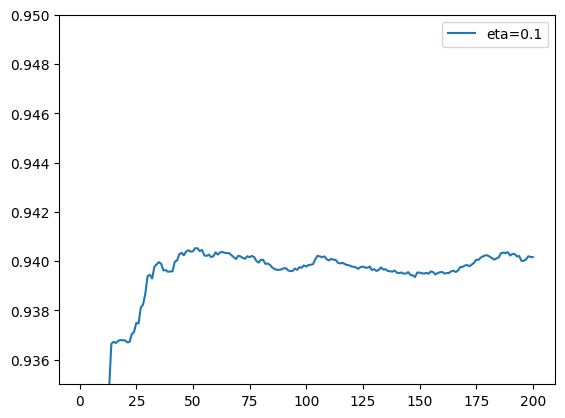

In [92]:
for eta, df_result in scores.items():
    plt.plot(df_result.iter, df_result.val_auc, label=eta)

plt.ylim(0.935, 0.950)
plt.legend()


Para eta seleccionamos 0.1 con el corte en 50

In [93]:
scores = {}

In [94]:
xgb_params = {
    'eta': 0.1, 
    'max_depth': 10,
    'min_child_weight': 5,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 42,
    'verbosity': 1,
}

evals_result = {}
model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist,
                  evals_result=evals_result)

key = f'max_depth={xgb_params['max_depth']}'
scores[key] = get_xgb_scores(evals_result)



[0]	train-auc:0.93982	val-auc:0.92217
[5]	train-auc:0.95516	val-auc:0.93674
[10]	train-auc:0.96062	val-auc:0.93698
[15]	train-auc:0.96462	val-auc:0.93826
[20]	train-auc:0.96756	val-auc:0.93928
[25]	train-auc:0.96979	val-auc:0.93999
[30]	train-auc:0.97158	val-auc:0.94020
[35]	train-auc:0.97326	val-auc:0.94075
[40]	train-auc:0.97493	val-auc:0.94082
[45]	train-auc:0.97638	val-auc:0.94086
[50]	train-auc:0.97777	val-auc:0.94043
[55]	train-auc:0.97950	val-auc:0.94056
[60]	train-auc:0.98086	val-auc:0.94038
[65]	train-auc:0.98223	val-auc:0.94096
[70]	train-auc:0.98324	val-auc:0.94114
[75]	train-auc:0.98431	val-auc:0.94097
[80]	train-auc:0.98523	val-auc:0.94084
[85]	train-auc:0.98608	val-auc:0.94038
[90]	train-auc:0.98707	val-auc:0.93985
[95]	train-auc:0.98787	val-auc:0.93965
[100]	train-auc:0.98841	val-auc:0.93930
[105]	train-auc:0.98920	val-auc:0.93918
[110]	train-auc:0.99029	val-auc:0.93906
[115]	train-auc:0.99114	val-auc:0.93868
[120]	train-auc:0.99182	val-auc:0.93872
[125]	train-auc:0.9925

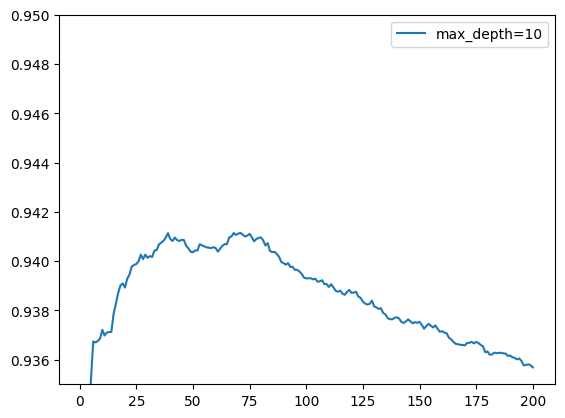

In [95]:
for max_depth, df_result in scores.items():
    plt.plot(df_result.iter, df_result.val_auc, label=max_depth)
plt.ylim(0.935, 0.950)

plt.legend()

Mejor opcion de max_depth es 7

In [96]:
scores = {}

In [97]:
xgb_params = {
    'eta': 0.1, 
    'max_depth': 7,
    'min_child_weight': 20,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 42,
    'verbosity': 1,
}

evals_result = {}
model = xgb.train(xgb_params, dtrain, num_boost_round=50,
                  verbose_eval=5,
                  evals=watchlist,
                  evals_result=evals_result)

key = f'min_child_weight={xgb_params['min_child_weight']}'
scores[key] = get_xgb_scores(evals_result)


[0]	train-auc:0.92270	val-auc:0.92959
[5]	train-auc:0.93625	val-auc:0.93638
[10]	train-auc:0.93943	val-auc:0.93842
[15]	train-auc:0.94096	val-auc:0.93910
[20]	train-auc:0.94265	val-auc:0.93989
[25]	train-auc:0.94410	val-auc:0.94009
[30]	train-auc:0.94535	val-auc:0.94016
[35]	train-auc:0.94691	val-auc:0.94038
[40]	train-auc:0.94841	val-auc:0.94055
[45]	train-auc:0.94985	val-auc:0.94084
[49]	train-auc:0.95080	val-auc:0.94064


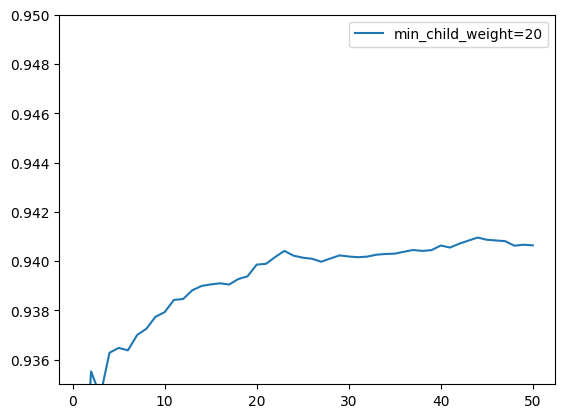

In [98]:
for min_child_weight, df_result in scores.items():
    plt.plot(df_result.iter, df_result.val_auc, label=min_child_weight)
plt.ylim(0.935, 0.950)
plt.legend()


Mejor min_child_weight es de 5

In [99]:
xgb_params = {
    'eta': 0.1, 
    'max_depth': 7,
    'min_child_weight': 5,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 42,
    'verbosity': 1,
}

evals_result = {}
model = xgb.train(xgb_params, dtrain, num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist,
                  evals_result=evals_result)





[0]	train-auc:0.93392	val-auc:0.92162
[5]	train-auc:0.94810	val-auc:0.93649
[10]	train-auc:0.95223	val-auc:0.93734
[15]	train-auc:0.95542	val-auc:0.93880
[20]	train-auc:0.95681	val-auc:0.93996
[25]	train-auc:0.95799	val-auc:0.94054
[30]	train-auc:0.95904	val-auc:0.94153
[35]	train-auc:0.96090	val-auc:0.94188
[40]	train-auc:0.96185	val-auc:0.94165
[45]	train-auc:0.96329	val-auc:0.94165
[50]	train-auc:0.96485	val-auc:0.94156
[55]	train-auc:0.96595	val-auc:0.94143
[60]	train-auc:0.96760	val-auc:0.94102
[65]	train-auc:0.96885	val-auc:0.94130
[70]	train-auc:0.97052	val-auc:0.94070
[75]	train-auc:0.97185	val-auc:0.94056
[80]	train-auc:0.97309	val-auc:0.94051
[85]	train-auc:0.97407	val-auc:0.94012
[90]	train-auc:0.97497	val-auc:0.93999
[95]	train-auc:0.97615	val-auc:0.93977
[100]	train-auc:0.97723	val-auc:0.93968
[105]	train-auc:0.97806	val-auc:0.93981
[110]	train-auc:0.97899	val-auc:0.93953
[115]	train-auc:0.98018	val-auc:0.93948
[120]	train-auc:0.98084	val-auc:0.93953
[125]	train-auc:0.9817

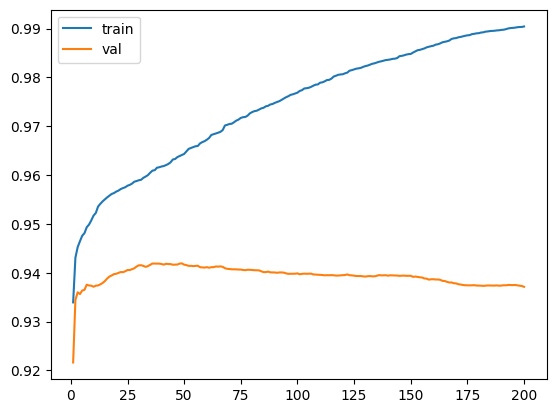

In [100]:
df_scores = get_xgb_scores(evals_result)

plt.plot(df_scores.iter, df_scores.train_auc, label='train')
plt.plot(df_scores.iter, df_scores.val_auc, label='val')
plt.legend()

In [127]:
xgb_params = {
    'eta': 0.1, 
    'max_depth': 7,
    'min_child_weight': 5,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 42,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=35)

In [128]:
y_pred_prob = model.predict(dval)

In [129]:
thresholds = np.linspace(0.01, 0.99, 100)

best_f1 = 0
best_threshold = 0

for t in thresholds:
    y_pred_p = (y_pred_prob >= t).astype(int)
    
    f1 = f1_score(y_val, y_pred_p)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Mejor_F1={best_f1}, Mejor_Corte= {best_threshold}")

Mejor_F1=0.7064439140811456, Mejor_Corte= 0.3465656565656566


In [130]:
y_pred_prob = model.predict(dval)
y_pred = (y_pred_prob >= 0.3466).astype(int)
sc_M4 = roc_auc_score(y_val, y_pred_prob)
F1_XGBOOST = f1_score(y_val, y_pred)

## Seleccion mejor modelo

In [131]:
print(f"ROC-AUC M1: {sc_M1:.4f}\n"
      f"F1 Score M1: {F1_accurracy:.4f}\n\n" # Salto doble

      f"ROC-AUC M2: {sc_M2:.4f}\n"
      f"F1 Score M2: {F1_TreeClassifier:.4f}\n\n" # Salto doble

      f"ROC-AUC M3: {sc_M3:.4f}\n"
      f"F1 Score M3: {F1_RandomForest:.4f}\n\n" # Salto doble

      f"ROC-AUC M4: {sc_M4:.4f}\n"
      f"F1 Score M4: {F1_XGBOOST:.4f}")

ROC-AUC M1: 0.8983
F1 Score M1: 0.5166

ROC-AUC M2: 0.9208
F1 Score M2: 0.5519

ROC-AUC M3: 0.9356
F1 Score M3: 0.5955

ROC-AUC M4: 0.9416
F1 Score M4: 0.7064


## Modelo FINAL con FULL TRAIN y TEST

In [132]:
scaler = StandardScaler()
df_full_train[numericas] = scaler.fit_transform(df_full_train[numericas])
df_test[numericas]   = scaler.transform(df_test[numericas])

In [133]:
X_full_train, X_test, dv = Dict_Vect(df_full_train, df_test)

In [134]:
features = list(dv.get_feature_names_out())

d_full_train = xgb.DMatrix(X_full_train, label=y_full_train, feature_names=features)
dtest = xgb.DMatrix(X_test, label=y_test, feature_names=features)

In [135]:
xgb_params = {
    'eta': 0.1, 
    'max_depth': 7,
    'min_child_weight': 5,

    'objective': 'binary:logistic',
    'eval_metric': 'auc',

    'nthread': 8,
    'seed': 42,
    'verbosity': 1,
}

model = xgb.train(xgb_params, d_full_train, num_boost_round=35)

In [136]:
y_pred_prob = model.predict(dtest)
y_pred = (y_pred_prob >= 0.3466).astype(int)
roc_auc_score(y_test, y_pred_prob),f1_score(y_test, y_pred)

sc_XGBOOST_final = roc_auc_score(y_test, y_pred_prob)
F1_XGBOOST_final = f1_score(y_test, y_pred)


In [137]:
sc_XGBOOST_final = roc_auc_score(y_test, y_pred_prob)
F1_XGBOOST_final = f1_score(y_test, y_pred)


In [138]:
print(f"ROC-AUC XGBOOST: {sc_M4:.4f}\n"
      f"F1 XGBOOST: {F1_XGBOOST:.4f}\n"
      f"BEST_THRESHOLD_TRAIN: {best_threshold:.4f}\n\n"

      f"ROC-AUC XGBOOST FINAL: {sc_XGBOOST_final:.4f}\n"
      f"F1 XGBOOST FINAL: {F1_XGBOOST_final:.4f}"
)

ROC-AUC XGBOOST: 0.9416
F1 XGBOOST: 0.7064
BEST_THRESHOLD_TRAIN: 0.3466

ROC-AUC XGBOOST FINAL: 0.9372
F1 XGBOOST FINAL: 0.6852
